# Binary Classification

## Data Generation

In [1]:
import motorch as mo
import motorch.nn as nn
import motorch.optim as optim
import motorch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

seed = 42
rng = np.random.default_rng(seed=seed)

In [2]:
def assign_labels(points: np.ndarray) -> np.ndarray:
  x, y = points[:, 0], points[:, 1]

  l1 = 2 - x    # x1 + x2 = 2
  l2 = x + 1    # x1 - x2 = -1
  l3 = 0

  enclosed = (y <= l1) & (y <= l2) & (y >= l3)

  return np.where(enclosed, 1, -1)

In [3]:
# Unit Test - Assigned labels should sum to zero
dummy_data = np.array([
    [0, 0],
    [0, 0.5],
    [0.5, 1.0],
    [1.5, 0.1],
    [1, 0],
    [-0.5, 0.5],
    [-0.5, 0.4],
    [-0.1, 0.8],
    [0.3, 1.1], # end positive
    [0, -0.01], # start negative
    [-1, 0.5],
    [0.5, 1.6],
    [1.5, 0.8],
    [-1.01, 0],
    [-0.5, -0.5],
    [-0.5, 0.9],
    [-0.1, -0.8],
    [0.3, -1.1]
])

dummy_labels = assign_labels(dummy_data)

assert dummy_labels.sum() == 0 # Expecting half positive, half negative


In [4]:
x1_low, x1_high = -0.5, 1.5    # Adjusted from -1.0, 2.0
x2_low, x2_high = -0.3, 1.72   # Adjusted from -0.5, 2.0

def generate_data(num_samples: int) -> np.ndarray:
  data = rng.uniform(
    low=[x1_low, x2_low],
    high=[x1_high, x2_high],
    size=(num_samples, 2)
  )

  assert data.shape == (num_samples, 2)

  labels = assign_labels(data)
  data = np.column_stack((data, labels))

  assert data.shape == (num_samples, 3)

  return data

In [5]:
num_samples = 1000

data = generate_data(num_samples)

percent_negative = np.mean(data[:, 2] == -1)
percent_positive = 1 - percent_negative

print(f"Class Ratio:")
print("-"*15)
print(f"Positive: {percent_positive:.2f}%")
print(f"Negative: {percent_negative:.2f}%")

Class Ratio:
---------------
Positive: 0.50%
Negative: 0.50%


## Manual Weights with Sign Activation

In [6]:
layer1_size = (2, 3)
layer2_size = (3, 1)

class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(*layer1_size)
    self.act1 = nn.Sgn()
    self.output = nn.Linear(*layer2_size)
    self.act2 = nn.Sgn()

  def forward(self, x):
    x = self.layer1(x)
    x = self.act1(x)
    x = self.output(x)
    x = self.act2(x)
    return x

In [7]:
model = MLP()

# First layer
w_11 = mo.tensor([-1, -1])
b_11 = 2
w_12 = mo.tensor([1, -1])
b_12 = 1
w_13 = mo.tensor([0, 2])
b_13 = 0

layer1_weights = mo.column_stack((w_11, w_12, w_13))
layer1_biases = mo.tensor([b_11, b_12, b_13]).reshape(1, -1)

# Second layer
w_21 = mo.ones(layer2_size)
b_21 = mo.tensor([-2.5]).reshape(1, 1)

nn.init.from_tensor(model.layer1.weight, layer1_weights)
nn.init.from_tensor(model.layer1.bias, layer1_biases)
nn.init.from_tensor(model.output.weight, w_21)
nn.init.from_tensor(model.output.bias, b_21)

print(model)
for name, param in model.named_parameters():
  print(f"{name}: {param}")

MLP(
  (layer1): Linear(in_features=2, out_features=3, bias=True)
  (act1): Sgn()
  (output): Linear(in_features=3, out_features=1, bias=True)
  (act2): Sgn()
)
weight: Parameter([[-1  1  0]
 [-1 -1  2]])
bias: Parameter([[2 1 0]])
weight: Parameter([[1.]
 [1.]
 [1.]])
bias: Parameter([[-2.5]])


In [8]:
# Unit Test - Model logits should average out to zero
dummy_data = mo.tensor(dummy_data)

preds = model(dummy_data)
assert preds.shape[0] == dummy_data.shape[0] and sum(preds) == 0

In [9]:
num_samples = 1000
data = mo.tensor(generate_data(num_samples))

train_x, train_y = data[:, :-1], data[:, -1].reshape(-1, 1)

print(f"Training data shape: {data.shape}")
print(f"Inputs shape: {train_x.shape}, labels shape: {train_y.shape}")

Training data shape: (1000, 3)
Inputs shape: (1000, 2), labels shape: (1000, 1)


In [10]:
def accuracy(x, y):
  return mo.mean(x == y)

preds = model(train_x)

train_acc = accuracy(preds, train_y)
print(f"Training Accuracy: {train_acc * 100:.2f}%")

Training Accuracy: 100.00%


In [11]:
def plot_preds(preds, x, y):
  if isinstance(preds, mo.Tensor):
    preds = preds.numpy().flatten()
  if isinstance(x, mo.Tensor):
    x = x.numpy()
  if isinstance(y, mo.Tensor):
    y = y.numpy().flatten()

  correct_mask = preds == y
  pos_mask = y == 1
  neg_mask = y == -1

  correct_pos_idx = np.nonzero(correct_mask & pos_mask)[0]
  correct_neg_idx = np.nonzero(correct_mask & neg_mask)[0]
  incorrect_idx = np.nonzero(~correct_mask)[0]

  fig, ax = plt.subplots(figsize=(7, 6))

  # Plot predicted points with labels
  ax.scatter(x[correct_pos_idx, 0],  x[correct_pos_idx, 1],
            c='red',   alpha=0.4, label='correct (+1)')
  ax.scatter(x[correct_neg_idx, 0],  x[correct_neg_idx, 1],
            c='blue',  alpha=0.4, label='correct (-1)')
  ax.scatter(x[incorrect_idx, 0],     x[incorrect_idx, 1],
            c='black', marker='x', s=60, label='misclassified')

  # Draw the boundary region
  x_range = np.linspace(-2, 2, 200)
  ax.plot(x_range, 2 - x_range, 'g--', linewidth=1, label='x2 + x1 = 2')
  ax.plot(x_range, x_range + 1, 'b--', linewidth=1, label='x1 - x2 = -1')
  ax.axhline(0, color='purple', linestyle='--', linewidth=1, label='x2 = 0')

  ax.set_xlim(-2, 3)
  ax.set_ylim(-1, 3)
  ax.set_xticks(np.arange(x1_low, x1_high + 0.1, 0.5))
  ax.set_yticks(np.arange(x2_low, x2_high + 0.1, 0.5))

  ax.set_xlabel('x1')
  ax.set_ylabel('x2')
  ax.legend(loc='upper right')
  plt.title("Visualization of Predicted Labels")
  plt.show()

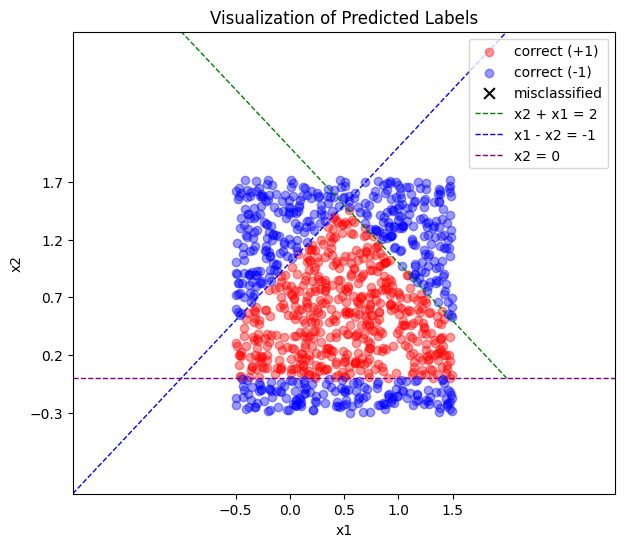

In [12]:
plot_preds(preds, train_x, train_y)

## Learned Weights with Sigmoid Activation

In [13]:
class AltSigmoid(nn.Module):
  def forward(self, x):
    self.grad = self._grad(x)
    return 2 * F.sigmoid(x) - 1

  def __str__(self):
    return "Alternate Sigmoid: 2 * sigmoid(x) - 1\n"

  def _grad(self, x):
    return 2 * F.sigmoid_grad(x)

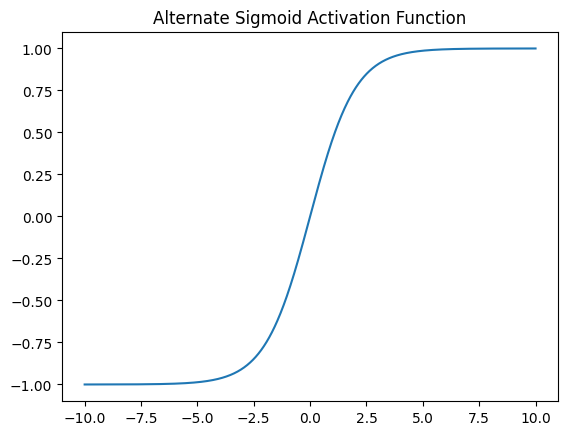

In [14]:
activation_fn = AltSigmoid()

# Verify activation fn shape
x = mo.tensor(np.linspace(-10, 10, 1000))
y = activation_fn(x)

fig, ax = plt.subplots()

ax.plot(x, y)
plt.title("Alternate Sigmoid Activation Function")
plt.show()

In [15]:
layer1_size = (2, 3)
layer2_size = (3, 1)

class AltSigmoidMLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(*layer1_size)
    self.act1 = AltSigmoid()
    self.output = nn.Linear(*layer2_size)
    self.act2 = AltSigmoid()

  def forward(self, x):
    x = self.layer1(x)
    x = self.act1(x)
    x = self.output(x)
    x = self.act2(x)
    return x

  # Custom backward
  def backwards(self, loss_fn):
    l2_grads = loss_fn.grad * self.act2.grad
    self.output.weight.grad = self.output.x.T @ l2_grads
    self.output.bias.grad = l2_grads.mean(axis=0)

    l1_grads = l2_grads @ self.output.weight.T * self.act1.grad
    self.layer1.weight.grad = self.layer1.x.T @ l1_grads
    self.layer1.bias.grad = l1_grads.mean(axis=0)
    

In [16]:
prop_vec = (0.8, 0.2)
num_samples = 1250
data = mo.tensor(generate_data(num_samples))

all_x, all_y = data[:, :-1], data[:, -1].reshape(-1, 1)

split_idx = int(prop_vec[0] * len(all_x))

train_x, train_y = all_x[:split_idx, :], all_y[:split_idx, :]
val_x, val_y = all_x[split_idx:, :], all_y[split_idx:, :]

model = AltSigmoidMLP()

# Set weights according to Glorot strategy
# cite: https://towardsdatascience.com/weight-initialization-and-activation-functions-in-deep-learning-50aac05c3533/
nn.init.glorot(rng, model.layer1.weight)
nn.init.zeros(model.layer1.bias)

nn.init.glorot(rng, model.output.weight)
nn.init.zeros(model.output.bias)

print(model)

AltSigmoidMLP(
  (layer1): Linear(in_features=2, out_features=3, bias=True)
  (act1): AltSigmoid()
  (output): Linear(in_features=3, out_features=1, bias=True)
  (act2): AltSigmoid()
)


In [17]:
logits = model(train_x)
# RAW logits [-1, 1] - should select class +1 if >= 0, else -1
preds = mo.where(logits >= 0, 1, -1)

train_acc = accuracy(preds, train_y)
print(f"Accuracy before training: {train_acc}")

Accuracy before training: 0.604


In [18]:
lr = 0.8
num_epochs = 30_000

loss_fn = nn.LogisticLoss()
optimizer = optim.SGD(model.parameters(), lr=lr)

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for i in range(num_epochs):
  optimizer.zero_grad()

  # Sort the batch
  sort_idx = rng.permutation(len(train_x))
  batch_x = train_x[sort_idx]
  batch_y = train_y[sort_idx]

  # Make predictions
  logits = model(batch_x)

  # Calc metrics
  train_loss = loss_fn(logits, batch_y)
  preds = mo.where(logits >= 0, 1, -1)
  train_acc = accuracy(preds, batch_y)

  # Backprop + Gradient Descent
  model.backwards(loss_fn)
  optimizer.step()

  # Get validation metrics
  logits = model(val_x)
  val_loss = loss_fn(logits, val_y)
  preds = mo.where(logits >= 0, 1, -1)
  val_acc = accuracy(preds, val_y)

  # Record metrics
  train_losses.append(train_loss)
  train_accs.append(train_acc)
  val_losses.append(val_loss)
  val_accs.append(val_acc)

  # Print stats
  if i % 1000 == 0:
    print(f"Epoch: {i}, Train Accuracy: {train_acc:.3f}, "\
          f"Train Loss: {train_loss:.3f}, ")
    print(f"          Val Accuracy: {val_acc:.3f}, Val Loss: {val_loss:.3f}")


AttributeError: 'LogisticLoss' object has no attribute 'grad'

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

# Loss on left axis
ax.plot(val_losses, color='coral', label='loss')

# Accuracy on right axis
ax.plot(val_accs, color='steelblue', label='accuracy')

ax.set_xlabel('epoch')
plt.title('Validation Loss and Accuracy Over Training')
plt.legend()
fig.tight_layout()
plt.show()

In [ ]:
data = mo.tensor(generate_data(200))
test_x, test_y = data[:, :-1], data[:, -1].reshape(-1, 1)

logits = model(test_x)
preds = mo.where(logits >= 0, 1, -1)
acc = accuracy(preds, test_y)

print(f"Test Accuracy: {acc * 100:.2f}%")

plot_preds(preds, test_x, test_y)